# Questão 1

Comparação entre a DTFT contínua e a DFT amostrada para o sinal finito
`x[n] = δ[n] - δ[n-1] + δ[n-2] - δ[n-3]`, usando `N` em `{4, 16, 64, 1024}`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()

def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_4').exists():
            return candidate
    raise FileNotFoundError(
        'Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.'
    )

REPO_ROOT = find_repo_root(CWD)


In [2]:
def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))



In [3]:
x = np.array([1.0, -1.0, 1.0, -1.0])
n = np.arange(len(x))
omega = np.linspace(-np.pi, np.pi, 4096)
X_dtft = np.sum(x[:, None] * np.exp(-1j * n[:, None] * omega[None, :]), axis=0)

Ns = [4, 16, 64, 1024]
rows = []
spectra = {}

for N in Ns:
    X_dft = np.fft.fft(x, n=N)
    omega_k = 2 * np.pi * np.arange(N) / N
    omega_k_wrapped = (omega_k + np.pi) % (2 * np.pi) - np.pi
    order = np.argsort(omega_k_wrapped)
    spectra[N] = (omega_k_wrapped[order], X_dft[order])
    rows.append(
        {
            'N': N,
            'Passo angular (rad)': 2 * np.pi / N,
            'Maior magnitude DFT': float(np.max(np.abs(X_dft))),
        }
    )

display_rows(rows, float_digits=8)


N    | Passo angular (rad) | Maior magnitude DFT
-----+---------------------+--------------------
4    | 1.57079633          | 4.00000000         
16   | 0.39269908          | 4.00000000         
64   | 0.09817477          | 4.00000000         
1024 | 0.00613592          | 4.00000000         


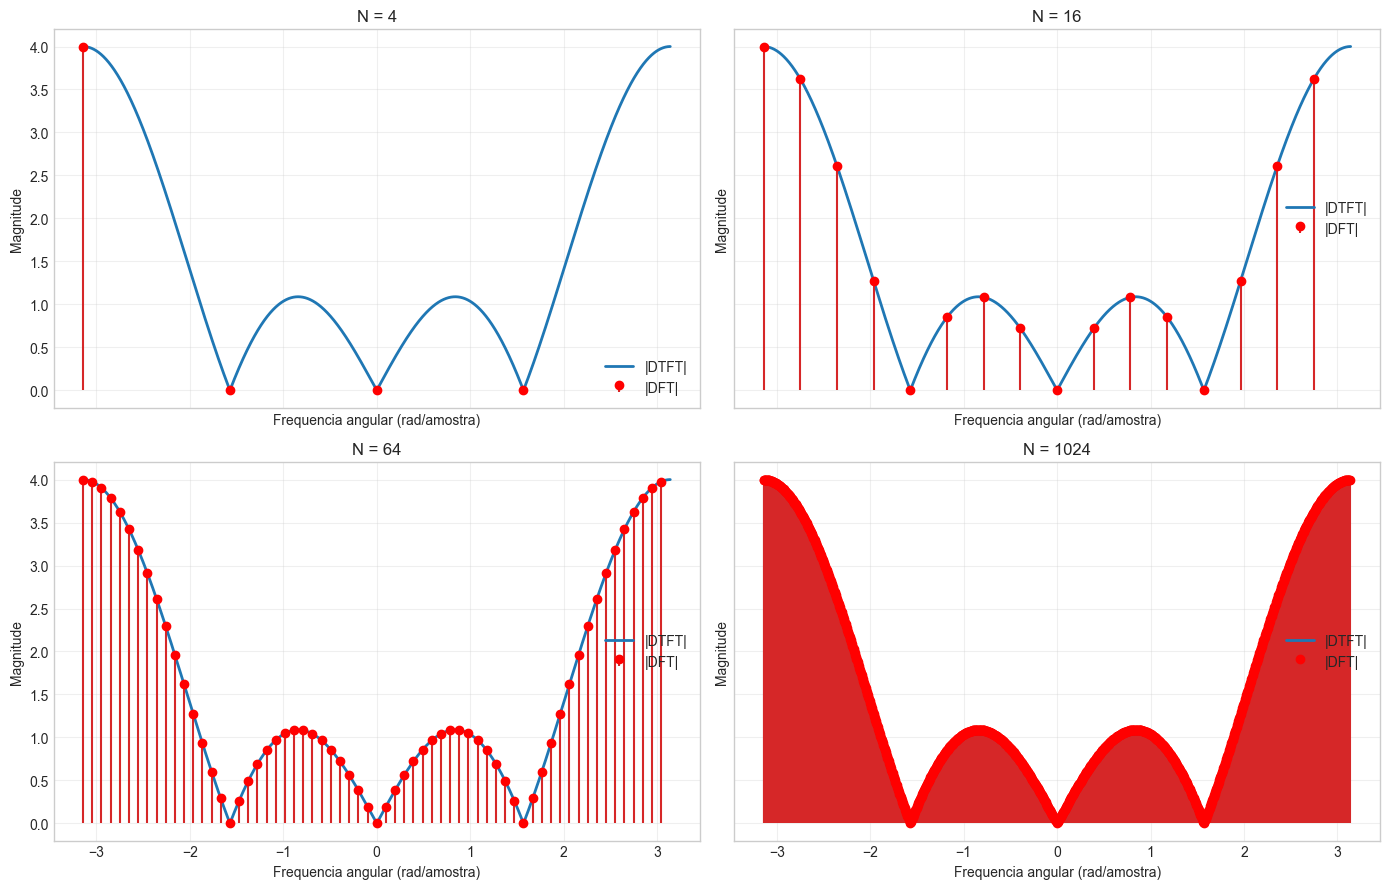

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, N in zip(axes.ravel(), Ns):
    omega_k, X_dft = spectra[N]
    ax.plot(omega, np.abs(X_dtft), label='|DTFT|', linewidth=2)
    ax.stem(omega_k, np.abs(X_dft), linefmt='tab:red', markerfmt='ro', basefmt=' ', label='|DFT|')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Frequencia angular (rad/amostra)')
    ax.set_ylabel('Magnitude')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Comentários

- A DTFT descreve a resposta espectral contínua do sinal finito.
- A DFT apenas amostra essa curva em `N` frequências discretas.
- Quando `N` aumenta, os pontos da DFT ficam mais densos e a aproximação visual da DTFT melhora.
- O aumento de `N` não muda o conteúdo espectral do sinal, apenas a grade em que ele é observado.
